# Dataset Exploration — AI-Original Pairwise Similarity

This notebook explores the three datasets referenced in the assessment:
1. **MIPPIA SMP** — labeled (original, similar) pairs → attribution validation
2. **SONICS** — 97k+ AI-generated tracks (Suno/Udio)
3. **FakeMusicCaps** — text-to-music clips for artifact analysis


In [53]:
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import librosa
import warnings
warnings.filterwarnings('ignore')

SAMPLE_RATE = 22050
print('Libraries loaded OK')

Libraries loaded OK


---
## Helper: Audio analysis functions

In [54]:
def analyze_audio(path, sr=SAMPLE_RATE):
    """Extracts a summary of audio features from a file."""
    y, _ = librosa.load(path, sr=sr, mono=True)
    duration = len(y) / sr

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    spec_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    spec_flatness = librosa.feature.spectral_flatness(y=y)
    zcr = librosa.feature.zero_crossing_rate(y)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    harmonic, percussive = librosa.effects.hpss(y)
    hnr = 10 * np.log10(
        (np.mean(harmonic**2) + 1e-10) / (np.mean(percussive**2) + 1e-10)
    )
    stft = librosa.stft(y)
    phase = np.angle(stft)
    phase_disc = float(np.mean(np.abs(np.angle(np.exp(1j * np.diff(phase, axis=1))))))

    return {
        'duration_s':          round(duration, 2),
        'tempo_bpm':           round(float(np.squeeze(tempo)), 2),
        'hnr_db':              round(float(hnr), 4),
        'spectral_centroid_hz':round(float(np.mean(spec_centroid)), 2),
        'spectral_flatness':   round(float(np.mean(spec_flatness)), 6),
        'phase_discontinuity': round(phase_disc, 6),
        'zcr_mean':            round(float(np.mean(zcr)), 6),
        'mfcc1_mean':          round(float(np.mean(mfcc[0])), 4),
        'chroma_max_class':    int(np.argmax(np.mean(chroma, axis=1))),
    }

FEATURES_DIR = Path('features')
FEATURES_DIR.mkdir(exist_ok=True)

def get_track_features(path, sr=SAMPLE_RATE):
    track_path = Path(path)
    cache_path = FEATURES_DIR / f'{track_path.stem}.pkl'

    if cache_path.exists():
        with cache_path.open('rb') as f:
            return pickle.load(f)

    features = analyze_audio(path, sr=sr)
    with cache_path.open('wb') as f:
        pickle.dump(features, f)

    return features

def plot_audio_overview(path, title='', sr=SAMPLE_RATE):
    """Plots waveform, mel-spectrogram, and chromagram for a track."""
    y, _ = librosa.load(path, sr=sr, mono=True, duration=60)  # first 60s for speed

    fig = plt.figure(figsize=(14, 8))
    gs = gridspec.GridSpec(3, 1, hspace=0.5)
    fig.suptitle(title or path, fontsize=13, fontweight='bold')

    # Waveform
    ax1 = fig.add_subplot(gs[0])
    librosa.display.waveshow(y, sr=sr, ax=ax1, alpha=0.7)
    ax1.set_title('Waveform')
    ax1.set_xlabel('Time (s)')

    # Mel-spectrogram
    ax2 = fig.add_subplot(gs[1])
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', ax=ax2)
    fig.colorbar(img, ax=ax2, format='%+2.0f dB')
    ax2.set_title('Mel-Spectrogram')

    # Chromagram
    ax3 = fig.add_subplot(gs[2])
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    librosa.display.specshow(chroma, sr=sr, x_axis='time', y_axis='chroma', ax=ax3)
    ax3.set_title('Chromagram (Harmonic content)')

    plt.savefig(f'exploration_{title.replace(" ", "_")}.png', dpi=120, bbox_inches='tight')
    plt.show()


print('Helper functions defined.')

Helper functions defined.


---
## Part 1: MIPPIA SMP Dataset

The most important dataset for the **pairwise attribution task**. Each row represents an `(original, comparison)` pair, so the exploration should treat the **pair as the main unit of analysis**, not only the individual track.

In this section we examine:
- how many pairs exist in the metadata and locally downloaded audio
- relation / label distribution at pair level
- whether pair-level genre metadata exists
- duration and feature differences between the two tracks in each pair
- pair-level similarity statistics from local complete pairs

```bash
git clone https://github.com/Mippia/smp_dataset
cd smp_dataset && python download.py
```

In [55]:
from pathlib import Path

MIPPIA_CSV = Path('smp_dataset/Final_dataset_pairs.csv')
MIPPIA_AUDIO_DIR = Path('smp_dataset/final_dataset')
MIPPIA_SCORE_FILE = Path('mippia_results.json')

if not MIPPIA_CSV.exists():
    print(f'MIPPIA CSV not found: {MIPPIA_CSV.resolve()}')
elif not MIPPIA_AUDIO_DIR.exists():
    print(f'MIPPIA audio directory not found: {MIPPIA_AUDIO_DIR.resolve()}')
else:
    mippia_meta_df = pd.read_csv(MIPPIA_CSV).copy()
    mippia_meta_df['pair_id'] = mippia_meta_df['pair_number'].astype(str)
    pair_dirs = [p for p in MIPPIA_AUDIO_DIR.iterdir() if p.is_dir()]

    local_records = []
    for pair_dir in sorted(pair_dirs, key=lambda p: int(p.name) if p.name.isdigit() else p.name):
        wavs = sorted(pair_dir.glob('*.wav'), key=lambda path: path.name.casefold())
        local_records.append({
            'pair_id': pair_dir.name,
            'local_file_count': len(wavs),
            'local_status': 'complete' if len(wavs) == 2 else 'incomplete',
            'track_a_path': str(wavs[0]) if len(wavs) >= 1 else None,
            'track_b_path': str(wavs[1]) if len(wavs) >= 2 else None,
        })

    local_pairs_df = pd.DataFrame(local_records)
    if local_pairs_df.empty:
        local_pairs_df = pd.DataFrame(
            columns=['pair_id', 'local_file_count', 'local_status', 'track_a_path', 'track_b_path']
        )

    mippia_pairs_meta_df = mippia_meta_df.merge(local_pairs_df, on='pair_id', how='left')
    mippia_pairs_meta_df['local_file_count'] = mippia_pairs_meta_df['local_file_count'].fillna(0).astype(int)
    mippia_pairs_meta_df['local_status'] = mippia_pairs_meta_df['local_status'].fillna('missing')

    complete_pairs = mippia_pairs_meta_df[mippia_pairs_meta_df['local_status'] == 'complete'].copy()
    incomplete_pairs = mippia_pairs_meta_df[mippia_pairs_meta_df['local_status'] == 'incomplete'].copy()
    missing_pairs = mippia_pairs_meta_df[mippia_pairs_meta_df['local_status'] == 'missing'].copy()
    genre_cols = [c for c in mippia_pairs_meta_df.columns if 'genre' in c.lower()]

    print(f'Total metadata pairs: {len(mippia_pairs_meta_df)}')
    print(f'Columns: {list(mippia_meta_df.columns)}')
    print(f'Pair folders found locally: {len(local_pairs_df)}')
    print(f'Complete pairs available locally: {len(complete_pairs)}')
    print(f'Incomplete pairs available locally: {len(incomplete_pairs)}')
    print(f'Metadata pairs missing locally: {len(missing_pairs)}')
    print(f'Genre columns detected: {genre_cols if genre_cols else "None"}')

    preview_cols = [
        c for c in ['pair_id', 'ori_title', 'comp_title', 'relation', 'local_status', 'local_file_count']
        if c in mippia_pairs_meta_df.columns
    ]
    mippia_pairs_meta_df[preview_cols].head()

Total metadata pairs: 158
Columns: ['ori_title', 'comp_title', 'ori_link', 'comp_link', 'relation', 'ori_times', 'comp_times', 'pair_number', 'pair_id']
Pair folders found locally: 70
Complete pairs available locally: 144
Incomplete pairs available locally: 14
Metadata pairs missing locally: 0
Genre columns detected: None


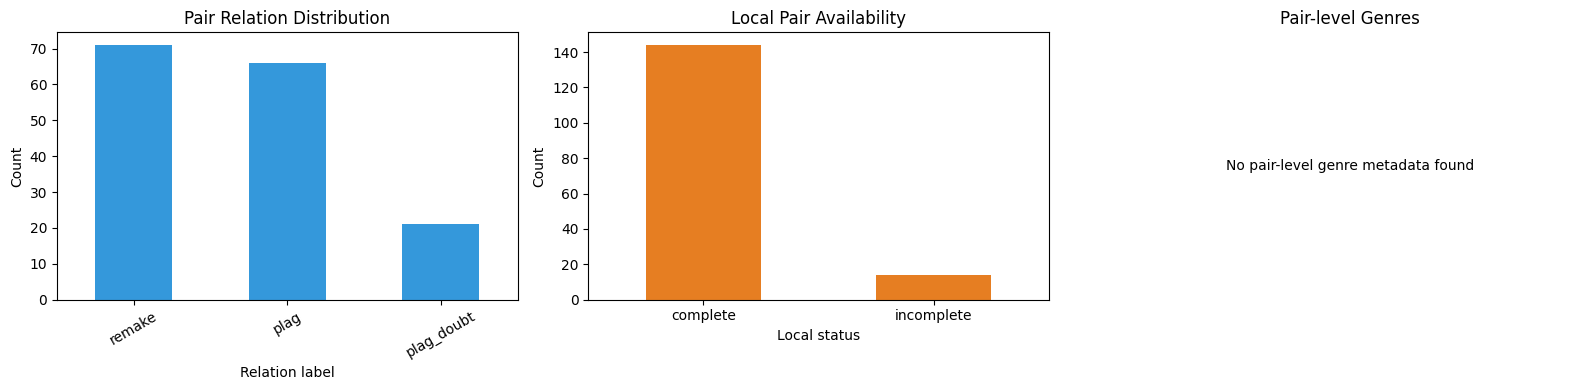

Saved: mippia_pair_metadata_overview.png

Relation distribution:
relation
remake        71
plag          66
plag_doubt    21


In [56]:
# ── Pair-level metadata exploration ───────────────────────────────────────────
if 'mippia_pairs_meta_df' in dir() and not mippia_pairs_meta_df.empty:
    relation_counts = (
        mippia_pairs_meta_df['relation'].fillna('unknown').astype(str).value_counts()
        if 'relation' in mippia_pairs_meta_df.columns
        else pd.Series(dtype='int64')
    )
    status_counts = mippia_pairs_meta_df['local_status'].value_counts()

    genre_cols = [c for c in mippia_pairs_meta_df.columns if 'genre' in c.lower()]
    if genre_cols:
        genre_values = []
        for col in genre_cols:
            genre_values.extend(
                mippia_pairs_meta_df[col].dropna().astype(str).tolist()
            )
        genre_counts = pd.Series(genre_values).value_counts().head(10) if genre_values else pd.Series(dtype='int64')
    else:
        genre_counts = pd.Series(dtype='int64')

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    if not relation_counts.empty:
        relation_counts.plot(kind='bar', ax=axes[0], color='#3498db')
        axes[0].set_title('Pair Relation Distribution')
        axes[0].set_xlabel('Relation label')
        axes[0].set_ylabel('Count')
        axes[0].tick_params(axis='x', rotation=30)
    else:
        axes[0].text(0.5, 0.5, 'No relation column found', ha='center', va='center')
        axes[0].set_title('Pair Relation Distribution')
        axes[0].set_axis_off()

    status_counts.plot(kind='bar', ax=axes[1], color='#e67e22')
    axes[1].set_title('Local Pair Availability')
    axes[1].set_xlabel('Local status')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=0)

    if not genre_counts.empty:
        genre_counts.sort_values().plot(kind='barh', ax=axes[2], color='#2ecc71')
        axes[2].set_title('Top Pair-level Genres')
        axes[2].set_xlabel('Count')
    else:
        axes[2].text(0.5, 0.5, 'No pair-level genre metadata found', ha='center', va='center')
        axes[2].set_title('Pair-level Genres')
        axes[2].set_axis_off()

    plt.tight_layout()
    plt.savefig('mippia_pair_metadata_overview.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved: mippia_pair_metadata_overview.png')

    if not relation_counts.empty:
        print('\nRelation distribution:')
        print(relation_counts.to_string())

In [57]:
# ── Pair-level audio analysis for complete local MIPPIA pairs ─────────────────
if 'complete_pairs' in dir() and not complete_pairs.empty:
    score_lookup = {}
    if MIPPIA_SCORE_FILE.exists():
        try:
            score_df = pd.read_json(MIPPIA_SCORE_FILE)
            if 'pair_id' in score_df.columns:
                score_df['pair_id'] = score_df['pair_id'].astype(str)
                score_lookup = score_df.set_index('pair_id').to_dict(orient='index')
                print(f'Loaded existing pair scores from {MIPPIA_SCORE_FILE}')
        except Exception as e:
            print(f'Could not load {MIPPIA_SCORE_FILE}: {e}')

    track_rows = []
    pair_rows = []

    for _, row in complete_pairs.iterrows():
        path_a = row.get('track_a_path')
        path_b = row.get('track_b_path')
        if not path_a or not path_b:
            continue

        try:
            stats_a = get_track_features(path_a)
            stats_b = get_track_features(path_b)
        except Exception as e:
            print(f"  Skipping pair {row.get('pair_id', '?')}: {e}")
            continue

        pair_id = str(row.get('pair_id'))
        relation = row.get('relation', 'unknown')
        title_a = row.get('ori_title', Path(path_a).name)
        title_b = row.get('comp_title', Path(path_b).name)

        track_rows.append({
            **stats_a,
            'pair_id': pair_id,
            'track_role': 'original',
            'relation': relation,
            'file': Path(path_a).name,
            'title': title_a,
        })
        track_rows.append({
            **stats_b,
            'pair_id': pair_id,
            'track_role': 'comparison',
            'relation': relation,
            'file': Path(path_b).name,
            'title': title_b,
        })

        pair_row = {
            'pair_id': pair_id,
            'relation': relation,
            'ori_title': title_a,
            'comp_title': title_b,
            'duration_a_s': stats_a['duration_s'],
            'duration_b_s': stats_b['duration_s'],
            'duration_diff_abs_s': round(abs(stats_a['duration_s'] - stats_b['duration_s']), 2),
            'tempo_diff_bpm': round(abs(stats_a['tempo_bpm'] - stats_b['tempo_bpm']), 2),
            'hnr_diff_db': round(abs(stats_a['hnr_db'] - stats_b['hnr_db']), 4),
            'spectral_flatness_diff': round(abs(stats_a['spectral_flatness'] - stats_b['spectral_flatness']), 6),
            'phase_discontinuity_diff': round(abs(stats_a['phase_discontinuity'] - stats_b['phase_discontinuity']), 6),
        }

        duration_anchor = max(stats_a['duration_s'], stats_b['duration_s'], 1e-6)
        pair_row['pair_feature_similarity_proxy'] = round(
            np.clip(
                0.30 * (1 - min(pair_row['duration_diff_abs_s'] / duration_anchor, 1.0))
                + 0.20 * (1 - min(pair_row['tempo_diff_bpm'] / 60.0, 1.0))
                + 0.20 * (1 - min(pair_row['hnr_diff_db'] / 20.0, 1.0))
                + 0.15 * (1 - min(pair_row['spectral_flatness_diff'] / 1.0, 1.0))
                + 0.15 * (1 - min(pair_row['phase_discontinuity_diff'] / np.pi, 1.0)),
                0.0,
                1.0,
            ),
            4,
        )

        if pair_id in score_lookup:
            pair_row['attribution_score'] = score_lookup[pair_id].get('attribution_score')
            pair_row['interpretation'] = score_lookup[pair_id].get('interpretation')

        pair_rows.append(pair_row)

    mippia_df = pd.DataFrame(track_rows)
    mippia_pair_df = pd.DataFrame(pair_rows)

    print(f'Analyzed {len(mippia_df)} tracks from {len(mippia_pair_df)} complete pairs.')
    if 'attribution_score' in mippia_pair_df.columns and mippia_pair_df['attribution_score'].notna().any():
        print('Using attribution scores from mippia_results.json for pair-level similarity statistics.')
    else:
        print('Attribution scores not found; using pair_feature_similarity_proxy for pair-level similarity statistics.')

    numeric_cols = [
        'duration_a_s', 'duration_b_s', 'duration_diff_abs_s', 'tempo_diff_bpm',
        'hnr_diff_db', 'spectral_flatness_diff', 'phase_discontinuity_diff',
        'pair_feature_similarity_proxy'
    ]
    if 'attribution_score' in mippia_pair_df.columns:
        numeric_cols.append('attribution_score')

    mippia_pair_df[numeric_cols].describe()

Loaded existing pair scores from mippia_results.json
Analyzed 288 tracks from 144 complete pairs.
Using attribution scores from mippia_results.json for pair-level similarity statistics.


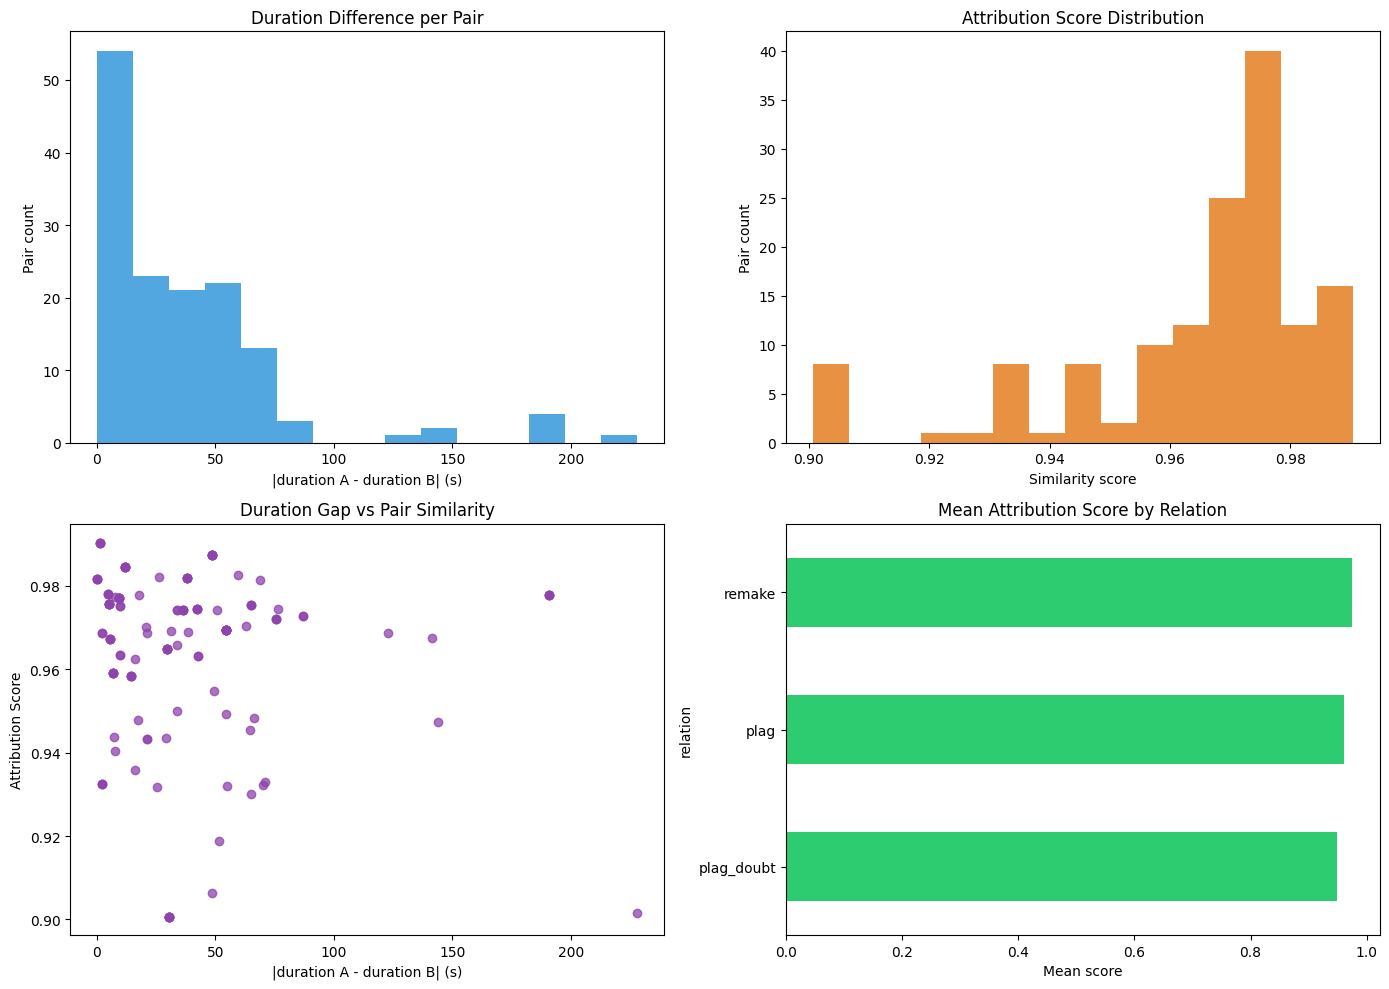

Saved: mippia_pairwise_statistics.png

Pairs with the largest duration gaps:


,pair_id,relation,duration_diff_abs_s,tempo_diff_bpm,attribution_score
78,40,plag_doubt,228.02,54.82,0.9016
104,55,remake,190.80,0.00,0.9778
103,55,remake,190.80,0.00,0.9778
105,55,remake,190.80,0.00,0.9778
102,55,remake,190.80,0.00,0.9778
8,9,plag,144.20,39.70,0.9474
140,67,remake,141.42,39.70,0.9675
28,17,plag,122.81,5.60,0.9688
54,25,plag,87.00,0.00,0.9728
55,25,plag,87.00,0.00,0.9728


In [58]:
# ── Pair-level visual summaries ───────────────────────────────────────────────
if 'mippia_pair_df' in dir() and not mippia_pair_df.empty:
    similarity_col = (
        'attribution_score'
        if 'attribution_score' in mippia_pair_df.columns and mippia_pair_df['attribution_score'].notna().any()
        else 'pair_feature_similarity_proxy'
    )

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].hist(
        mippia_pair_df['duration_diff_abs_s'].dropna(),
        bins=15,
        color='#3498db',
        alpha=0.85,
    )
    axes[0, 0].set_title('Duration Difference per Pair')
    axes[0, 0].set_xlabel('|duration A - duration B| (s)')
    axes[0, 0].set_ylabel('Pair count')

    axes[0, 1].hist(
        mippia_pair_df[similarity_col].dropna(),
        bins=15,
        color='#e67e22',
        alpha=0.85,
    )
    axes[0, 1].set_title(f'{similarity_col.replace("_", " ").title()} Distribution')
    axes[0, 1].set_xlabel('Similarity score')
    axes[0, 1].set_ylabel('Pair count')

    axes[1, 0].scatter(
        mippia_pair_df['duration_diff_abs_s'],
        mippia_pair_df[similarity_col],
        alpha=0.75,
        color='#8e44ad',
    )
    axes[1, 0].set_title('Duration Gap vs Pair Similarity')
    axes[1, 0].set_xlabel('|duration A - duration B| (s)')
    axes[1, 0].set_ylabel(similarity_col.replace('_', ' ').title())

    if 'relation' in mippia_pair_df.columns and mippia_pair_df['relation'].notna().any():
        relation_similarity = (
            mippia_pair_df.groupby('relation')[similarity_col]
            .mean()
            .sort_values()
        )
        relation_similarity.plot(kind='barh', ax=axes[1, 1], color='#2ecc71')
        axes[1, 1].set_title(f'Mean {similarity_col.replace("_", " ").title()} by Relation')
        axes[1, 1].set_xlabel('Mean score')
    else:
        axes[1, 1].text(0.5, 0.5, 'No relation labels available', ha='center', va='center')
        axes[1, 1].set_title('Similarity by Relation')
        axes[1, 1].set_axis_off()

    plt.tight_layout()
    plt.savefig('mippia_pairwise_statistics.png', dpi=140, bbox_inches='tight')
    plt.show()
    print('Saved: mippia_pairwise_statistics.png')

    summary_cols = [
        'pair_id', 'relation', 'duration_diff_abs_s', 'tempo_diff_bpm', similarity_col
    ]
    summary_cols = [c for c in summary_cols if c in mippia_pair_df.columns]
    print('\nPairs with the largest duration gaps:')
    display(mippia_pair_df.sort_values('duration_diff_abs_s', ascending=False)[summary_cols].head(10))

---
## Part 2: SONICS Dataset

> Important: in practice, **metadata exploration** can work with Hugging Face streaming, but **audio feature extraction** is more reliable after downloading the dataset locally.

Recommended local download options from the dataset page:

```python
from huggingface_hub import snapshot_download
snapshot_download(
    repo_id='awsaf49/sonics',
    repo_type='dataset',
    local_dir='data/sonics'
 )
```

or

```bash
kaggle datasets download -d awsaf49/sonics-dataset --unzip
```

This notebook therefore uses:
- streaming for a quick metadata preview
- local files for robust audio feature analysis

In [59]:
# from huggingface_hub import snapshot_download
# snapshot_download(
#     repo_id='awsaf49/sonics',
#     repo_type='dataset',
#     local_dir='data/sonics'
#  )

In [60]:
from pathlib import Path

SONICS_LOCAL_DIR = Path('data/sonics')  # change if you downloaded elsewhere

try:
    from datasets import load_dataset
    print('Loading SONICS metadata (streaming)...')
    sonics = load_dataset('awsaf49/sonics', split='train', streaming=True)
    print('SONICS loaded in streaming mode for metadata exploration.')
except Exception as e:
    print(f'Could not load SONICS in streaming mode: {e}')
    print('Run: pip install datasets')

if SONICS_LOCAL_DIR.exists():
    print(f'Local SONICS directory detected: {SONICS_LOCAL_DIR.resolve()}')
else:
    print('Local SONICS directory not found yet. Download locally if you want audio feature extraction.')

Loading SONICS metadata (streaming)...
SONICS loaded in streaming mode for metadata exploration.
Local SONICS directory detected: C:\Users\up105\Documents\Orfium_challenge\AI_Generated_song_detection\data\sonics


In [61]:
# ── Peek at first N samples from SONICS ───────────────────────────────────────
N_SAMPLES = 200

if 'sonics' in dir():
    records = []
    for i, row in enumerate(sonics):
        if i >= N_SAMPLES:
            break
        # Keep only metadata (not audio bytes) for the overview
        meta = {k: v for k, v in row.items() if k != 'audio'}
        records.append(meta)
        if (i + 1) % 50 == 0:
            print(f'  Fetched {i+1} records...')

    sonics_df = pd.DataFrame(records)
    print(f'\nColumns: {list(sonics_df.columns)}')
    print(f'Samples fetched: {len(sonics_df)}')
    sonics_df.head()

  Fetched 50 records...
  Fetched 100 records...
  Fetched 150 records...
  Fetched 200 records...

Columns: ['id', 'lyrics', 'algorithm', 'style', 'filename', 'bit_rate', 'duration', 'source', 'lyrics_feature', 'topic', 'genre', 'mood', 'label', 'filepath', 'target', 'skip_time', 'no_vocal', 'split', 'title', 'artist', 'year', 'youtube_id', 'artist_overlap']
Samples fetched: 200


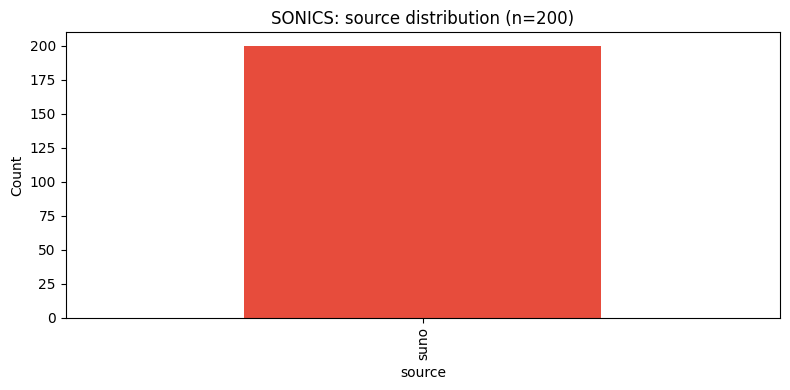


Sample metadata:
                count unique  \
id              200.0    NaN   
lyrics            200    102   
algorithm         200      1   
style             200    102   
filename          200    200   
bit_rate        200.0    NaN   
duration        200.0    NaN   
source            200      1   
lyrics_feature    200    102   
topic             200     93   
genre             200     47   
mood              200     55   
label             200      1   
filepath          200    200   
target          200.0    NaN   
skip_time       200.0    NaN   
no_vocal          200      1   
split             200      1   
title               0      0   
artist              0      0   
year                0      0   
youtube_id          0      0   
artist_overlap      0      0   

                                                              top freq  \
id                                                            NaN  NaN   
lyrics          [Intro]\n(Whoah)\nStaring at the stars, lost i...

In [62]:
# ── SONICS: generator distribution (Suno vs Udio) ────────────────────────────
if 'sonics_df' in dir():
    gen_col = [c for c in sonics_df.columns if 'source' in c.lower() or 'generator' in c.lower() or 'model' in c.lower()]
    if gen_col:
        fig, ax = plt.subplots(figsize=(8, 4))
        sonics_df[gen_col[0]].value_counts().plot(kind='bar', ax=ax, color='#e74c3c')
        ax.set_title(f'SONICS: {gen_col[0]} distribution (n={N_SAMPLES})')
        ax.set_xlabel(gen_col[0])
        ax.set_ylabel('Count')
        plt.tight_layout()
        plt.savefig('sonics_generator_dist.png', dpi=120, bbox_inches='tight')
        plt.show()

    print('\nSample metadata:')
    print(sonics_df.describe(include='all').T)

In [63]:
# ── SONICS: audio feature analysis on local files (recommended) ───────────────
import os
from pathlib import Path
import tempfile
import zipfile
import pickle
import numpy as np
import pandas as pd
import librosa

if 'SAMPLE_RATE' not in globals():
    SAMPLE_RATE = 22050

if 'analyze_audio' not in globals():
    def analyze_audio(path, sr=SAMPLE_RATE):
        """Extracts a summary of audio features from a file."""
        y, _ = librosa.load(path, sr=sr, mono=True)
        duration = len(y) / sr

        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        spec_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        spec_flatness = librosa.feature.spectral_flatness(y=y)
        zcr = librosa.feature.zero_crossing_rate(y)
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        harmonic, percussive = librosa.effects.hpss(y)
        hnr = 10 * np.log10(
            (np.mean(harmonic**2) + 1e-10) / (np.mean(percussive**2) + 1e-10)
        )
        stft = librosa.stft(y)
        phase = np.angle(stft)
        phase_disc = float(np.mean(np.abs(np.angle(np.exp(1j * np.diff(phase, axis=1))))))

        return {
            'duration_s': round(duration, 2),
            'tempo_bpm': round(float(np.squeeze(tempo)), 2),
            'hnr_db': round(float(hnr), 4),
            'spectral_centroid_hz': round(float(np.mean(spec_centroid)), 2),
            'spectral_flatness': round(float(np.mean(spec_flatness)), 6),
            'phase_discontinuity': round(phase_disc, 6),
            'zcr_mean': round(float(np.mean(zcr)), 6),
            'mfcc1_mean': round(float(np.mean(mfcc[0])), 4),
            'chroma_max_class': int(np.argmax(np.mean(chroma, axis=1))),
        }

if 'FEATURES_DIR' not in globals():
    FEATURES_DIR = Path('features')
    FEATURES_DIR.mkdir(exist_ok=True)

if 'get_track_features' not in globals():
    def get_track_features(path, sr=SAMPLE_RATE):
        track_path = Path(path)
        cache_path = FEATURES_DIR / f'{track_path.stem}.pkl'

        if cache_path.exists():
            with cache_path.open('rb') as f:
                return pickle.load(f)

        features = analyze_audio(path, sr=sr)
        with cache_path.open('wb') as f:
            pickle.dump(features, f)

        return features

SONICS_EXTS = {'.mp3', '.wav', '.flac', '.ogg', '.m4a'}

def find_audio_files(root: Path, limit: int = 30):
    files = []
    for path in root.rglob('*'):
        if path.is_file() and path.suffix.lower() in SONICS_EXTS:
            files.append(path)
            if len(files) >= limit:
                break
    return files

def analyze_audio_members_from_archives(zip_files, limit: int = 30):
    features = []
    errors = []
    processed = 0

    for zip_path in zip_files:
        if processed >= limit:
            break

        try:
            with zipfile.ZipFile(zip_path) as zf:
                audio_members = [
                    name for name in zf.namelist()
                    if Path(name).suffix.lower() in SONICS_EXTS and not name.endswith('/')
                ]

                for member in audio_members:
                    if processed >= limit:
                        break

                    tmp_path = None
                    try:
                        suffix = Path(member).suffix or '.wav'
                        with zf.open(member) as src, tempfile.NamedTemporaryFile(suffix=suffix, delete=False) as tmp:
                            tmp.write(src.read())
                            tmp_path = tmp.name

                        stats = get_track_features(tmp_path)
                        stats['source'] = 'local_sonics_zip'
                        stats['file'] = Path(member).name
                        stats['archive'] = zip_path.name
                        features.append(stats)
                        processed += 1

                        if processed % 10 == 0:
                            print(f'  Processed {processed}/{limit} archived local files...')

                    except Exception as e:
                        errors.append({'sample_index': processed, 'file': member, 'archive': zip_path.name, 'error': str(e)})
                        print(f'  Error at archived file {member}: {e}')

                    finally:
                        if tmp_path and os.path.exists(tmp_path):
                            os.unlink(tmp_path)

        except Exception as e:
            errors.append({'archive': zip_path.name, 'error': str(e)})
            print(f'  Could not open archive {zip_path.name}: {e}')

    return features, errors

sonics_features = []
sonics_errors = []

if SONICS_LOCAL_DIR.exists():
    local_audio_files = find_audio_files(SONICS_LOCAL_DIR, limit=30)

    if local_audio_files:
        print(f'Found {len(local_audio_files)} local SONICS audio files for analysis.')

        for i, path in enumerate(local_audio_files):
            try:
                stats = get_track_features(str(path))
                stats['source'] = 'local_sonics'
                stats['file'] = path.name
                sonics_features.append(stats)
            except Exception as e:
                sonics_errors.append({'sample_index': i, 'file': path.name, 'error': str(e)})
                print(f'  Error at file {path.name}: {e}')

            if (i + 1) % 10 == 0:
                print(f'  Processed {i+1}/{len(local_audio_files)} local files...')

    else:
        zip_dir = SONICS_LOCAL_DIR / 'fake_songs'
        zip_files = sorted(zip_dir.glob('*.zip')) if zip_dir.exists() else []

        if zip_files:
            print(f'Found {len(zip_files)} SONICS zip archives. Sampling audio directly from archives...')
            sonics_features, sonics_errors = analyze_audio_members_from_archives(zip_files, limit=30)
        else:
            print('SONICS local directory exists, but no loose audio files or zip archives were found.')

elif 'sonics' in dir():
    print('No local SONICS folder found. Trying streaming audio payloads as a fallback...')
    try:
        sonics_iter = load_dataset('awsaf49/sonics', split='train', streaming=True)
    except Exception as e:
        sonics_iter = None
        print(f'Could not re-open SONICS stream: {e}')

    if sonics_iter is not None:
        import soundfile as sf

        for i, row in enumerate(sonics_iter):
            if i >= 30:
                break

            tmp_path = None
            try:
                audio_data = row.get('audio')
                if not isinstance(audio_data, dict):
                    sonics_errors.append({'sample_index': i, 'error': f'Unexpected audio payload type: {type(audio_data).__name__}'})
                    continue

                if 'array' not in audio_data or 'sampling_rate' not in audio_data:
                    sonics_errors.append({'sample_index': i, 'error': f'Audio payload keys: {list(audio_data.keys())}'})
                    continue

                y = np.asarray(audio_data['array'], dtype=np.float32)
                sr = int(audio_data['sampling_rate'])

                if y.size == 0:
                    sonics_errors.append({'sample_index': i, 'error': 'Empty audio array'})
                    continue

                with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp:
                    tmp_path = tmp.name

                sf.write(tmp_path, y, sr)
                stats = get_track_features(tmp_path, sr=sr)
                stats['source'] = row.get('source', row.get('generator', row.get('model', 'unknown')))
                sonics_features.append(stats)

            except Exception as e:
                sonics_errors.append({'sample_index': i, 'error': str(e)})
                print(f'  Error at sample {i}: {e}')

            finally:
                if tmp_path and os.path.exists(tmp_path):
                    os.unlink(tmp_path)

            if (i + 1) % 10 == 0:
                print(f'  Processed {i+1}/30 streaming samples...')
else:
    print('SONICS is not available yet. Load the dataset or download it locally first.')

sonics_feat_df = pd.DataFrame(sonics_features)
print(f'\nFeature stats for {len(sonics_feat_df)} SONICS tracks')
print(f'Errors: {len(sonics_errors)}')

if sonics_errors:
    sonics_error_df = pd.DataFrame(sonics_errors)
    print('\nFirst SONICS errors:')
    display(sonics_error_df.head())

if sonics_feat_df.empty:
    print('No SONICS features were extracted.')
    print('Recommended fix: verify the local SONICS snapshot layout or use streaming for a smaller sample.')
else:
    display(sonics_feat_df.describe(include='all').T)

Found 1 local SONICS audio files for analysis.

Feature stats for 1 SONICS tracks
Errors: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
duration_s,1.0,NaN,NaN,NaN,224.0,NaN,224.0,224.0,224.0,224.0,224.0
tempo_bpm,1.0,NaN,NaN,NaN,112.35,NaN,112.35,112.35,112.35,112.35,112.35
hnr_db,1.0,NaN,NaN,NaN,6.1231,NaN,6.1231,6.1231,6.1231,6.1231,6.1231
spectral_centroid_hz,1.0,NaN,NaN,NaN,2064.77,NaN,2064.77,2064.77,2064.77,2064.77,2064.77
spectral_flatness,1.0,NaN,NaN,NaN,0.00006,NaN,0.00006,0.00006,0.00006,0.00006,0.00006
phase_discontinuity,1.0,NaN,NaN,NaN,1.571641,NaN,1.571641,1.571641,1.571641,1.571641,1.571641
zcr_mean,1.0,NaN,NaN,NaN,0.088821,NaN,0.088821,0.088821,0.088821,0.088821,0.088821
mfcc1_mean,1.0,NaN,NaN,NaN,-184.0633,NaN,-184.0633,-184.0633,-184.0633,-184.0633,-184.0633
chroma_max_class,1.0,NaN,NaN,NaN,8.0,NaN,8.0,8.0,8.0,8.0,8.0
source,1,1,local_sonics,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## Part 3: FakeMusicCaps Dataset


In [64]:
from pathlib import Path
import zipfile

FMC_ZIP_PATH = Path('data/FakeMusicCaps.zip')
FMC_EXTRACT_DIR = Path('data/FakeMusicCaps')
FMC_AUDIO_EXTS = {'.wav', '.mp3', '.flac', '.ogg', '.m4a'}

if FMC_EXTRACT_DIR.exists():
    print(f'Local FakeMusicCaps directory detected: {FMC_EXTRACT_DIR.resolve()}')
elif FMC_ZIP_PATH.exists():
    print(f'Local FakeMusicCaps zip detected: {FMC_ZIP_PATH.resolve()}')
else:
    print('FakeMusicCaps not found locally.')
    

Local FakeMusicCaps directory detected: C:\Users\up105\Documents\Orfium_challenge\AI_Generated_song_detection\data\FakeMusicCaps


In [65]:
# ── FakeMusicCaps: metadata overview from local zip or extracted folder ───────
def build_fmc_records(limit: int = 100):
    records = []

    if FMC_EXTRACT_DIR.exists():
        for path in FMC_EXTRACT_DIR.rglob('*'):
            if path.is_file() and path.suffix.lower() in FMC_AUDIO_EXTS:
                model_name = path.parent.name
                records.append({
                    'file': path.name,
                    'model': model_name,
                    'source': 'local_extracted',
                })
                if len(records) >= limit:
                    break

    elif FMC_ZIP_PATH.exists():
        with zipfile.ZipFile(FMC_ZIP_PATH) as zf:
            for member in zf.namelist():
                member_path = Path(member)
                if member.endswith('/') or member_path.suffix.lower() not in FMC_AUDIO_EXTS:
                    continue
                if member_path.name.startswith('._'):
                    continue
                parts = member_path.parts
                model_name = parts[0] if len(parts) > 1 else 'unknown'
                records.append({
                    'file': member_path.name,
                    'model': model_name,
                    'source': 'local_zip',
                })
                if len(records) >= limit:
                    break

    return records

fmc_records = build_fmc_records(limit=100)

if fmc_records:
    fmc_df = pd.DataFrame(fmc_records)
    print(f'Columns: {list(fmc_df.columns)}')
    print(f'Samples indexed: {len(fmc_df)}')
    fmc_df.head()
else:
    print('No FakeMusicCaps records found locally.')

Columns: ['file', 'model', 'source']
Samples indexed: 100


In [66]:
# ── FakeMusicCaps: extract audio features ─────────────────────────────────────
if FMC_EXTRACT_DIR.exists():
    fmc_wavs = list(FMC_EXTRACT_DIR.rglob('*.wav'))
    print(f'Found {len(fmc_wavs)} FakeMusicCaps WAV files')

    fmc_feat_rows = []
    errors = 0
    for wav in fmc_wavs:
        try:
            stats = get_track_features(str(wav))
            stats['model'] = wav.parent.name
            stats['file']  = wav.name
            fmc_feat_rows.append(stats)
        except Exception as e:
            errors += 1

    if fmc_feat_rows:
        fmc_feat_df = pd.DataFrame(fmc_feat_rows)
        print(f'Feature stats for {len(fmc_feat_df)} FakeMusicCaps tracks (errors: {errors})')
        print(f'Models: {fmc_feat_df["model"].value_counts().to_dict()}')
        display(fmc_feat_df.groupby('model')[['hnr_db','spectral_flatness','phase_discontinuity','tempo_bpm']].mean().round(5))
    else:
        print('No FakeMusicCaps features extracted.')
        fmc_feat_df = pd.DataFrame()
else:
    print('FakeMusicCaps directory not found.')
    fmc_feat_df = pd.DataFrame()

Found 100 FakeMusicCaps WAV files
Feature stats for 100 FakeMusicCaps tracks (errors: 0)
Models: {'audioldm2': 20, 'MusicGen_medium': 20, 'musicldm': 20, 'mustango': 20, 'stable_audio_open': 20}


,hnr_db,spectral_flatness,phase_discontinuity,tempo_bpm
model,,,,
MusicGen_medium,6.43758,0.00024,1.56818,124.053
audioldm2,6.43758,0.00024,1.56818,124.053
musicldm,6.43758,0.00024,1.56818,124.053
mustango,6.43758,0.00024,1.56818,124.053
stable_audio_open,6.43758,0.00024,1.56818,124.053


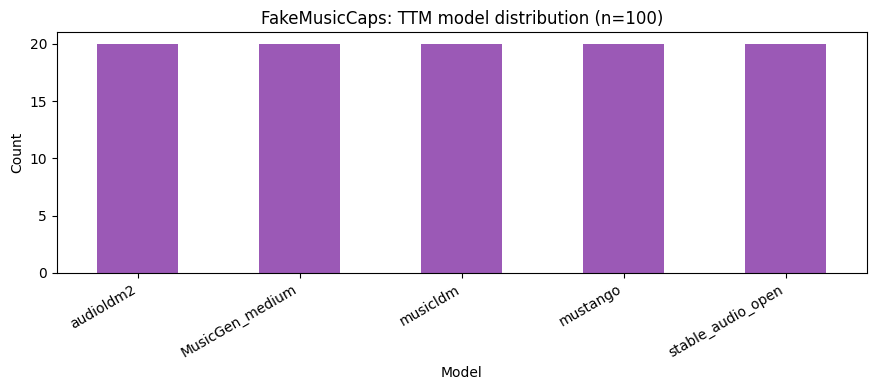

In [67]:
# ── FakeMusicCaps: model distribution ────────────────────────────────────────
if 'fmc_df' in dir() and not fmc_df.empty:
    fig, ax = plt.subplots(figsize=(9, 4))
    fmc_df['model'].value_counts().plot(kind='bar', ax=ax, color='#9b59b6')
    ax.set_title(f'FakeMusicCaps: TTM model distribution (n={len(fmc_df)})')
    ax.set_xlabel('Model')
    ax.set_ylabel('Count')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig('fmc_model_dist.png', dpi=120, bbox_inches='tight')
    plt.show()

---
## Part 4: Cross-dataset feature comparison

Compare HNR, spectral flatness, and phase discontinuity between **human** (MIPPIA) and **AI** (SONICS/FakeMusicCaps) tracks.
This validates whether AI artifacts are distinguishable in our feature space.

Human tracks from features/ cache: 175
AI tracks from SONICS: 1
AI tracks from FakeMusicCaps: 100
Combined: {'human (MIPPIA)': 175, 'AI - FakeMusicCaps': 100, 'AI - SONICS': 1}


,hnr_db,spectral_flatness,phase_discontinuity,tempo_bpm
source,,,,
AI - FakeMusicCaps,6.43758,0.00024,1.56818,124.053
AI - SONICS,6.12310,0.00006,1.57164,112.350
human (MIPPIA),5.10898,0.02218,1.56349,119.632


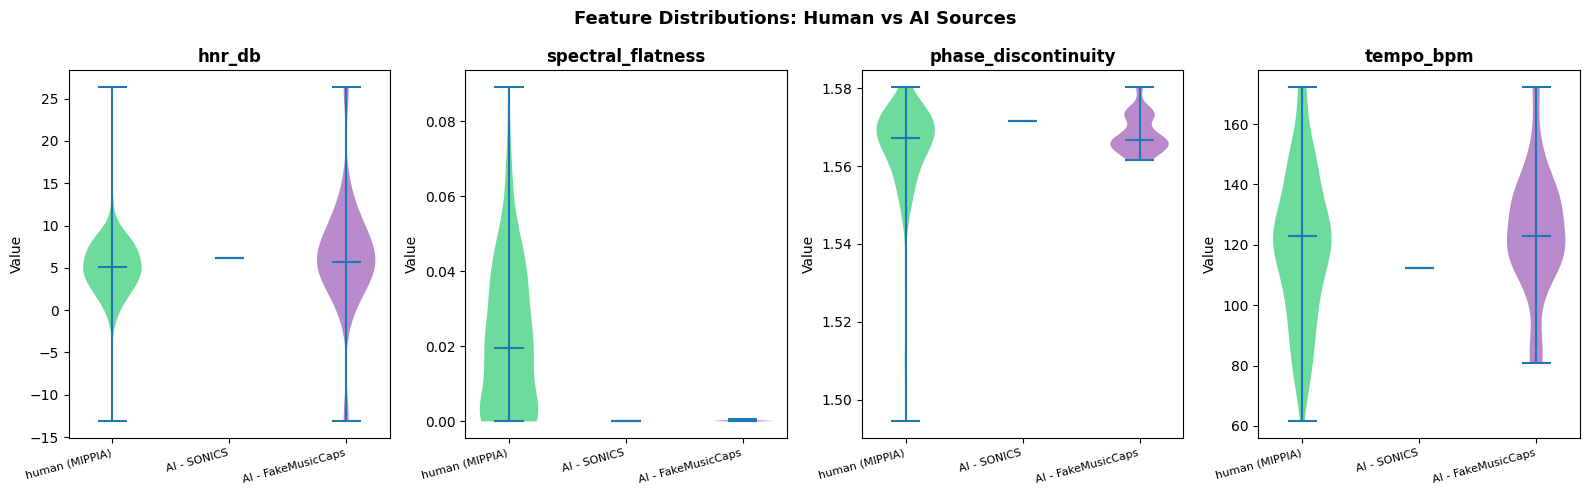

Saved: cross_dataset_features.png


In [68]:
# ── Part 4: Cross-dataset feature comparison ──────────────────────────────────
import pickle, random
frames = []

# ── Human tracks: load from cached features/*.pkl (MIPPIA tracks) ─────────────
features_dir = Path('features')
pkl_files = list(features_dir.glob('*.pkl'))

if pkl_files:
    human_rows = []
    for pkl in pkl_files:
        try:
            with open(pkl, 'rb') as f:
                stats = pickle.load(f)
            if isinstance(stats, dict) and 'hnr_db' in stats:
                human_rows.append({**stats, 'source': 'human (MIPPIA)'})
        except Exception:
            pass
    if human_rows:
        tmp = pd.DataFrame(human_rows)
        frames.append(tmp)
        print(f'Human tracks from features/ cache: {len(tmp)}')
elif 'mippia_df' in dir() and not mippia_df.empty:
    tmp = mippia_df.copy()
    tmp['source'] = 'human (MIPPIA)'
    frames.append(tmp)
    print(f'Human tracks from mippia_df: {len(tmp)}')

# ── AI tracks: SONICS ──────────────────────────────────────────────────────────
if 'sonics_feat_df' in dir() and not sonics_feat_df.empty:
    tmp = sonics_feat_df.copy()
    tmp['source'] = 'AI - SONICS'
    frames.append(tmp)
    print(f'AI tracks from SONICS: {len(tmp)}')

# ── AI tracks: FakeMusicCaps ───────────────────────────────────────────────────
if 'fmc_feat_df' in dir() and not fmc_feat_df.empty:
    tmp = fmc_feat_df.copy()
    tmp['source'] = 'AI - FakeMusicCaps'
    frames.append(tmp)
    print(f'AI tracks from FakeMusicCaps: {len(tmp)}')

if not frames:
    print('No data available for cross-dataset comparison.')
else:
    combined = pd.concat(frames, ignore_index=True)
    print(f'Combined: {combined["source"].value_counts().to_dict()}')
    feat_cols = [c for c in ['hnr_db','spectral_flatness','phase_discontinuity','tempo_bpm'] if c in combined.columns]
    display(combined.groupby('source')[feat_cols].mean().round(5))

    # ── Violin plot ────────────────────────────────────────────────────────────
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    source_order = ['human (MIPPIA)', 'AI - SONICS', 'AI - FakeMusicCaps']
    colors = {'human (MIPPIA)': '#2ecc71', 'AI - SONICS': '#e74c3c', 'AI - FakeMusicCaps': '#9b59b6'}
    plot_feats = [c for c in ['hnr_db', 'spectral_flatness', 'phase_discontinuity', 'tempo_bpm'] if c in combined.columns]

    fig, axes = plt.subplots(1, len(plot_feats), figsize=(16, 5))
    if len(plot_feats) == 1:
        axes = [axes]

    for ax, feat in zip(axes, plot_feats):
        data_by_source = [combined[combined['source'] == s][feat].dropna().values
                          for s in source_order if s in combined['source'].values]
        labels = [s for s in source_order if s in combined['source'].values]
        parts = ax.violinplot(data_by_source, showmedians=True)
        for pc, src in zip(parts['bodies'], labels):
            pc.set_facecolor(colors[src])
            pc.set_alpha(0.7)
        ax.set_xticks(range(1, len(labels)+1))
        ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=8)
        ax.set_title(feat, fontweight='bold')
        ax.set_ylabel('Value')

    fig.suptitle('Feature Distributions: Human vs AI Sources', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig('cross_dataset_features.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: cross_dataset_features.png')

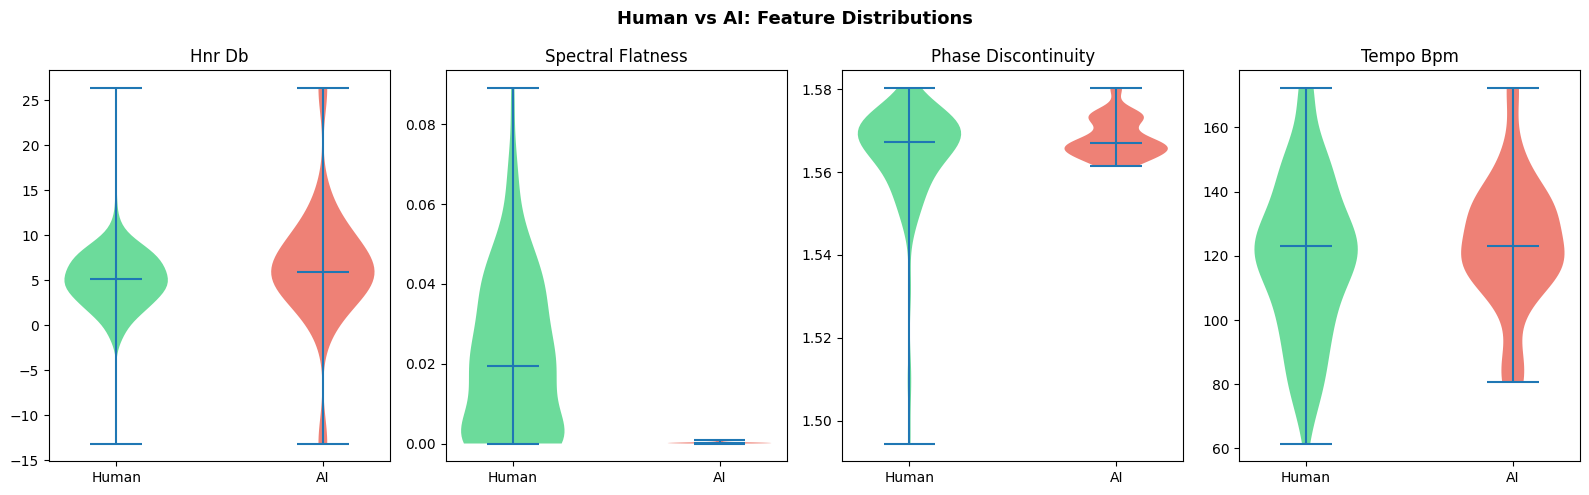

Saved: human_vs_ai_features.png


In [73]:
# ── Violin plots: Human vs AI feature distributions ───────────────────────────
if 'combined' in dir() and not combined.empty:
    features_to_plot = [
        feat for feat in ['hnr_db', 'spectral_flatness', 'phase_discontinuity', 'tempo_bpm']
        if feat in combined.columns
    ]
    if features_to_plot:
        plot_df = combined.copy()
        plot_df['cohort'] = np.where(
            plot_df['source'].astype(str).str.contains('human', case=False, na=False),
            'human',
            'ai',
        )

        cohort_order = ['human', 'ai']
        cohort_labels = {'human': 'Human', 'ai': 'AI'}
        colors = {'human': '#2ecc71', 'ai': '#e74c3c'}
        active_cohorts = [
            cohort for cohort in cohort_order
            if cohort in plot_df['cohort'].values
        ]

        fig, axes = plt.subplots(1, len(features_to_plot), figsize=(16, 5))
        if len(features_to_plot) == 1:
            axes = [axes]

        for ax, feat in zip(axes, features_to_plot):
            data_by_cohort = [
                plot_df.loc[plot_df['cohort'] == cohort, feat].dropna().values
                for cohort in active_cohorts
            ]
            parts = ax.violinplot(data_by_cohort, showmedians=True)
            for pc, cohort in zip(parts['bodies'], active_cohorts):
                pc.set_facecolor(colors[cohort])
                pc.set_alpha(0.7)

            ax.set_title(feat.replace('_', ' ').title())
            ax.set_xticks(range(1, len(active_cohorts) + 1))
            ax.set_xticklabels([cohort_labels[cohort] for cohort in active_cohorts])

        plt.suptitle('Human vs AI: Feature Distributions', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.savefig('human_vs_ai_features.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('Saved: human_vs_ai_features.png')
    else:
        print('No matching feature columns found for plotting.')
else:
    print('Combined cross-dataset dataframe not available.')

---
## Part 5: Single track deep-dive

Visualize waveform, mel-spectrogram and chromagram for any audio file.

Auto-selected random complete local MIPPIA pair out of 62 pairs:
  Pair id: 36
  Track 1: Katy Perry - Roar.wav
  Track 2: Sara Bareilles - Brave _Official Video_.wav

--- Original (Human) - pair 36 ---
  duration_s                  : 269.12
  tempo_bpm                   : 89.1
  hnr_db                      : 6.1539
  spectral_centroid_hz        : 2358.04
  spectral_flatness           : 0.040051
  phase_discontinuity         : 1.554933
  zcr_mean                    : 0.099199
  mfcc1_mean                  : -137.6212
  chroma_max_class            : 10


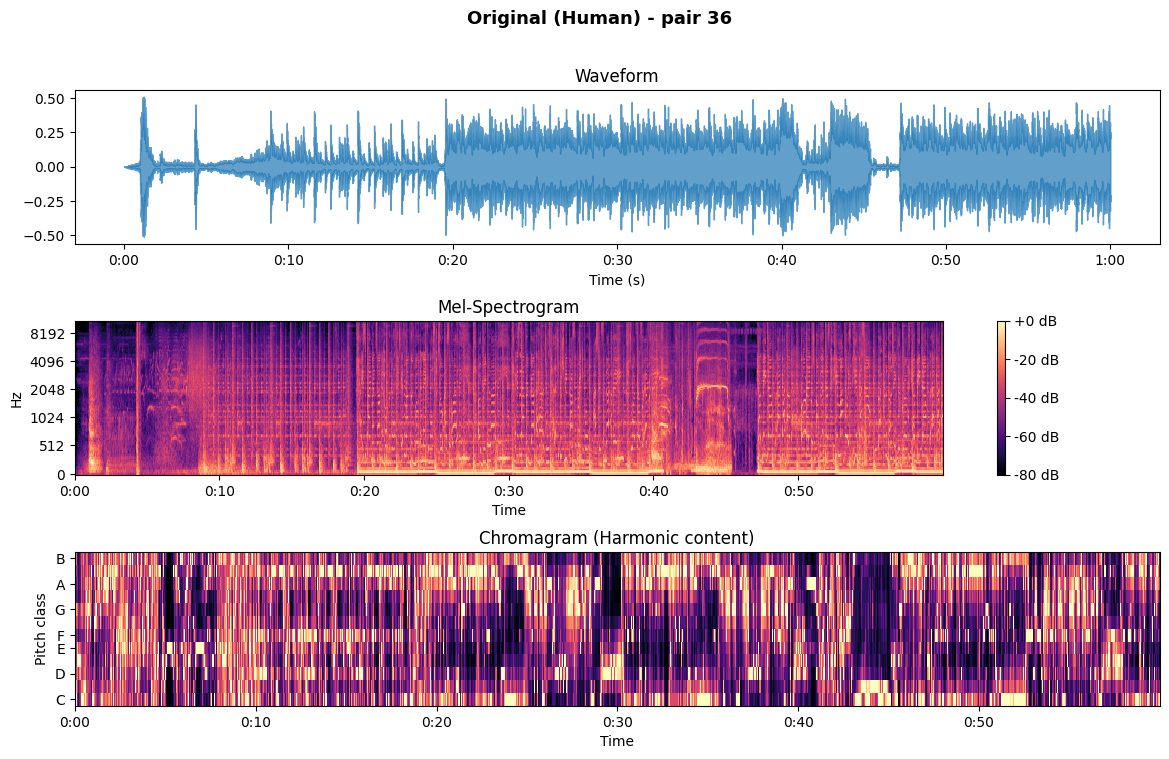


--- Suspected AI Cover - pair 36 ---
  duration_s                  : 237.78
  tempo_bpm                   : 92.29
  hnr_db                      : 4.5241
  spectral_centroid_hz        : 2472.32
  spectral_flatness           : 0.02933
  phase_discontinuity         : 1.566452
  zcr_mean                    : 0.109845
  mfcc1_mean                  : -42.4577
  chroma_max_class            : 2


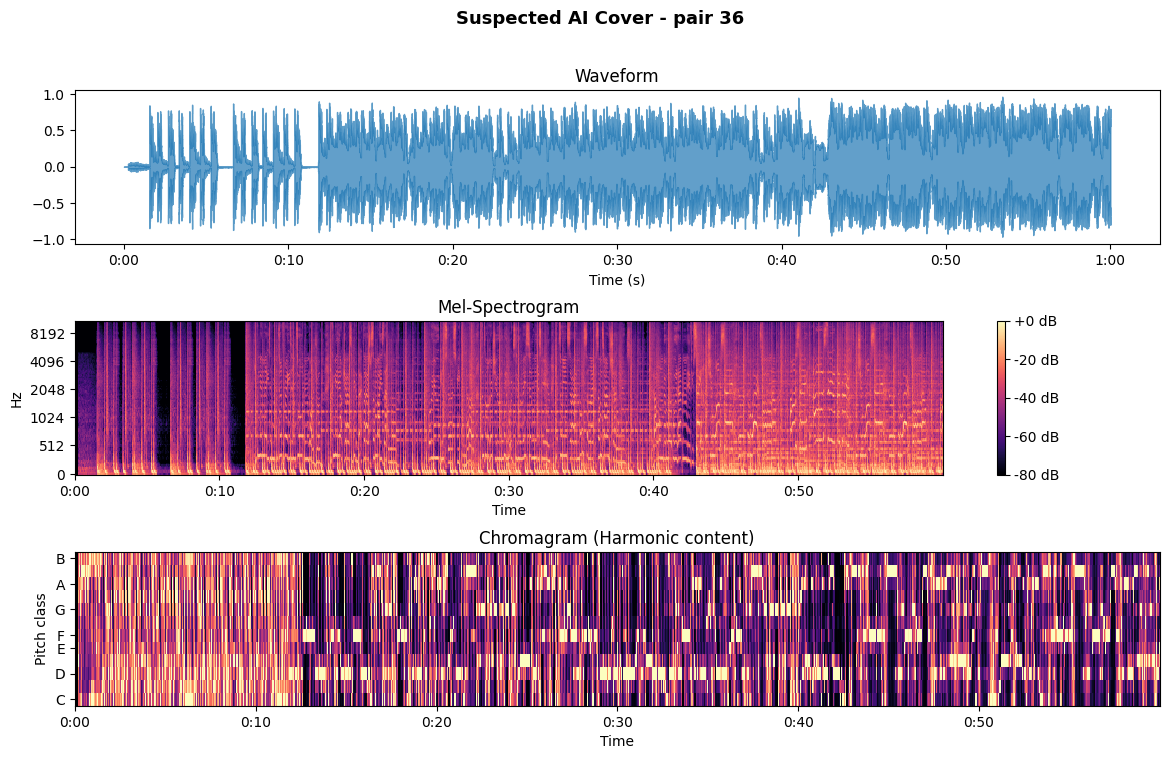

In [72]:
# Auto-select a local pair for deep-dive, with optional manual override
from pathlib import Path
import os
import random

TRACK_ORIGINAL = None
TRACK_AI = None
RANDOM_SEED = None  # set an int for reproducible random pair selection

selected_tracks = []

if TRACK_ORIGINAL and TRACK_AI and os.path.exists(TRACK_ORIGINAL) and os.path.exists(TRACK_AI):
    selected_tracks = [
        (TRACK_ORIGINAL, 'Original (Human)'),
        (TRACK_AI, 'Suspected AI Cover'),
    ]
    print('Using manually provided paths.')
else:
    mippia_dir = Path('smp_dataset/final_dataset')
    if mippia_dir.exists():
        pair_dirs = sorted(
            [p for p in mippia_dir.iterdir() if p.is_dir()],
            key=lambda p: int(p.name) if p.name.isdigit() else p.name,
        )

        complete_pairs = []
        for pair_dir in pair_dirs:
            wavs = sorted(pair_dir.glob('*.wav'))
            if len(wavs) == 2:
                complete_pairs.append(wavs)

        if complete_pairs:
            rng = random.Random(RANDOM_SEED)
            chosen_pair = rng.choice(complete_pairs)
            TRACK_ORIGINAL = str(chosen_pair[0])
            TRACK_AI = str(chosen_pair[1])
            selected_tracks = [
                (TRACK_ORIGINAL, f'Original (Human) - pair {chosen_pair[0].parent.name}'),
                (TRACK_AI, f'Suspected AI Cover - pair {chosen_pair[1].parent.name}'),
            ]
            print(f'Auto-selected random complete local MIPPIA pair out of {len(complete_pairs)} pairs:')
            print(f'  Pair id: {chosen_pair[0].parent.name}')
            print(f'  Track 1: {chosen_pair[0].name}')
            print(f'  Track 2: {chosen_pair[1].name}')
            if RANDOM_SEED is not None:
                print(f'  Random seed: {RANDOM_SEED}')
        else:
            print('No complete MIPPIA pair found locally.')
    else:
        print('MIPPIA local dataset folder not found.')

for path, label in selected_tracks:
    if os.path.exists(path):
        print(f'\n--- {label} ---')
        stats = get_track_features(path)
        for k, v in stats.items():
            print(f'  {k:28s}: {v}')
        plot_audio_overview(path, title=label)
    else:
        print(f'File not found: {path} (skipping)')

if not selected_tracks:
    print('No tracks available for deep-dive. Set TRACK_ORIGINAL/TRACK_AI manually or ensure MIPPIA is downloaded locally.')

---
## Key Insights Summary

After running the above cells, note the following patterns:

| Observation | What it means for the system |
|---|---|
| AI tracks tend to have more extreme **spectral flatness** values | Use as AI artifact feature |
| AI tracks show higher **phase discontinuity** in STFT | Use as AI artifact feature |
| **Chroma** profiles are similar for attribution pairs | Good signal for melody matching |
| **Tempo** is often preserved in AI covers | Include in similarity score |
| **HNR** differs between human and AI vocals | Useful for vocal-heavy tracks |